# Exploratory Data Analysis (EDA)

In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd
import os

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 16

## Load Audio Files

In [3]:
dataset_path = '../genres'

blues_track = os.path.join(dataset_path, 'blues', 'blues.00000.au')
metal_track = os.path.join(dataset_path, 'metal', 'metal.00000.au')

y_blues, sr = librosa.load(blues_track, sr=22050)
y_metal, _ = librosa.load(metal_track, sr=22050)

print(f"Audio Array Shape: {y_blues.shape}")
print(f"Sample Rate: {sr} Hz")
print(f"Duration: {len(y_blues)/sr} seconds")

Audio Array Shape: (661794,)
Sample Rate: 22050 Hz
Duration: 30.013333333333332 seconds


You can even listen to the audio directly in the notebook!

In [4]:
# print("Playing: Blues Track")
# ipd.display(ipd.Audio(y_blues, rate=sr))

## Visualize Waveform

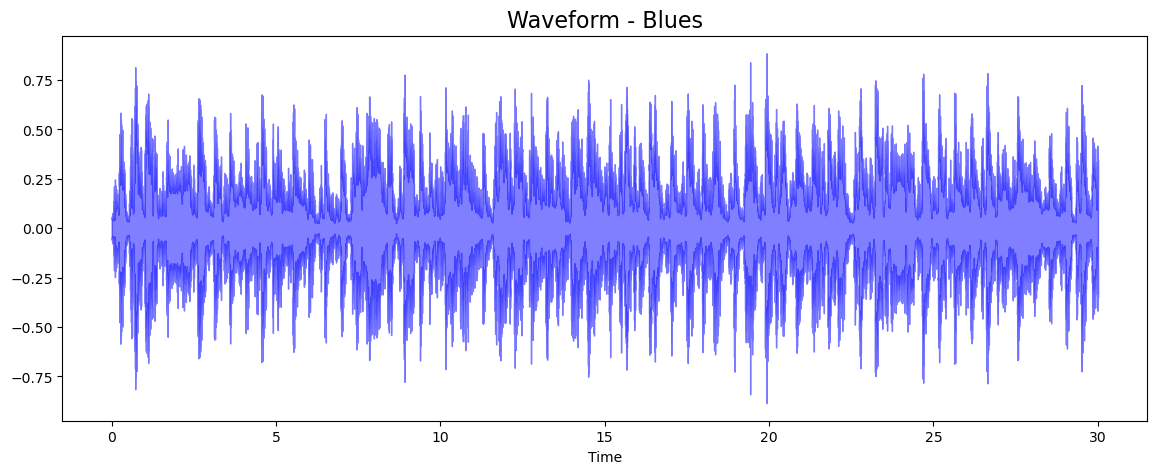

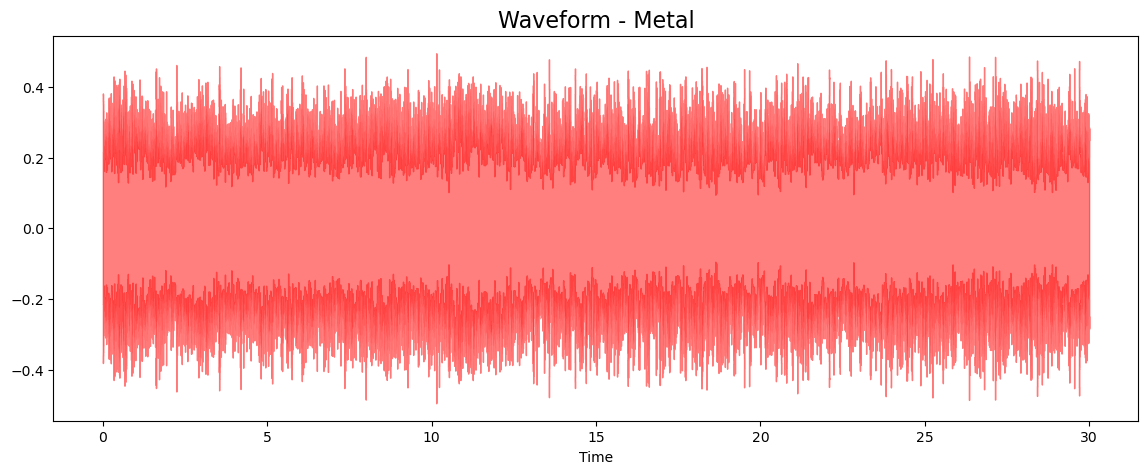

In [9]:
plt.figure()
plt.title('Waveform - Blues')
librosa.display.waveshow(y_blues, sr=sr, alpha=0.5, color='blue')
plt.show()

plt.figure()
plt.title('Waveform - Metal')
librosa.display.waveshow(y_metal, sr=sr, alpha=0.5, color='red')
plt.show()

## Visualize Spectrogram

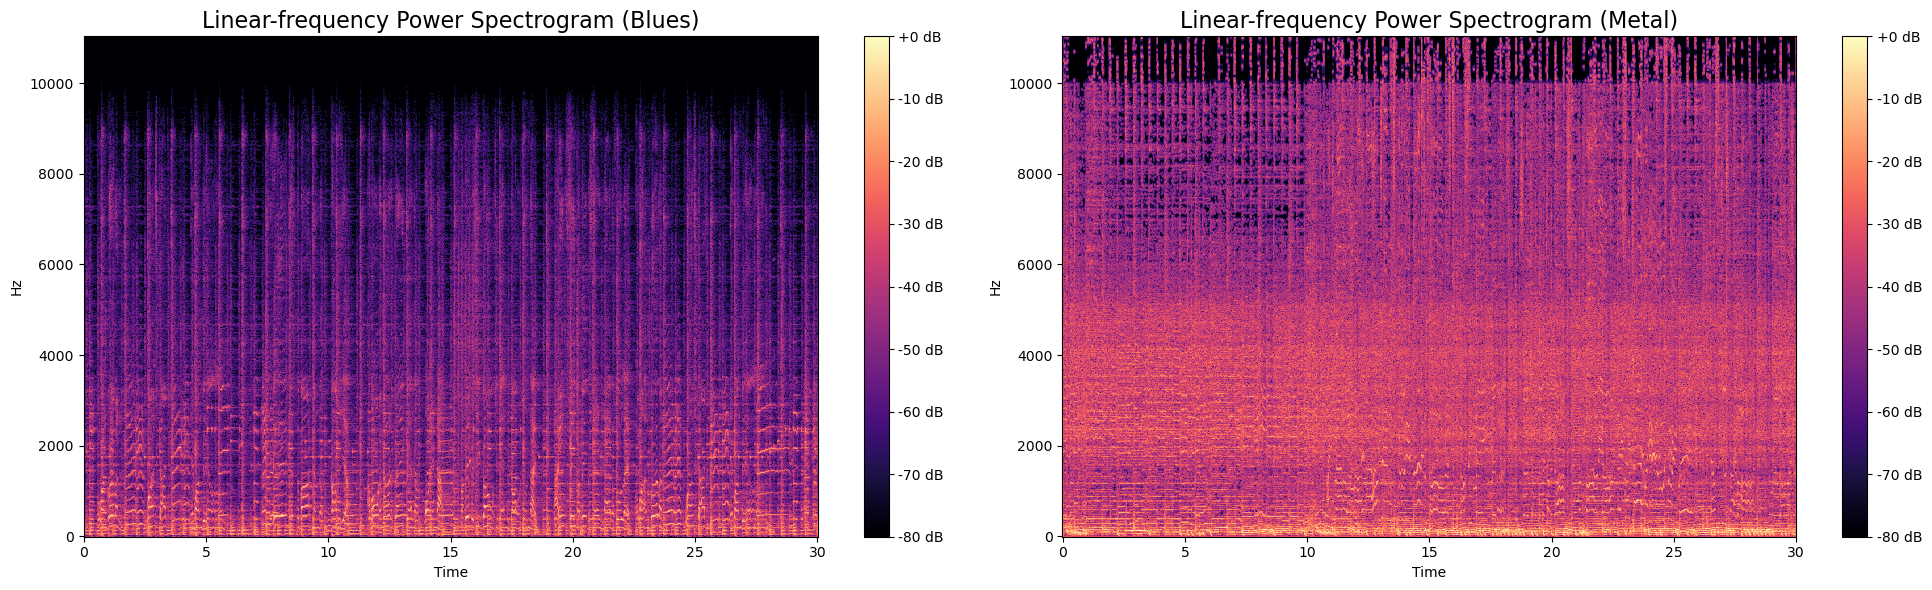

In [6]:
D_blues = librosa.amplitude_to_db(np.abs(librosa.stft(y_blues)), ref=np.max)
D_metal = librosa.amplitude_to_db(np.abs(librosa.stft(y_metal)), ref=np.max)

fig, ax = plt.subplots(1, 2, figsize=(20, 6))

img1 = librosa.display.specshow(D_blues, y_axis='hz', x_axis='time', ax=ax[0])
ax[0].set_title('Linear-frequency Power Spectrogram (Blues)')
fig.colorbar(img1, ax=ax[0], format='%+2.0f dB')

img2 = librosa.display.specshow(D_metal, y_axis='hz', x_axis='time', ax=ax[1])
ax[1].set_title('Linear-frequency Power Spectrogram (Metal)')
fig.colorbar(img2, ax=ax[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

## Mel-Spectrogram & MFCCs

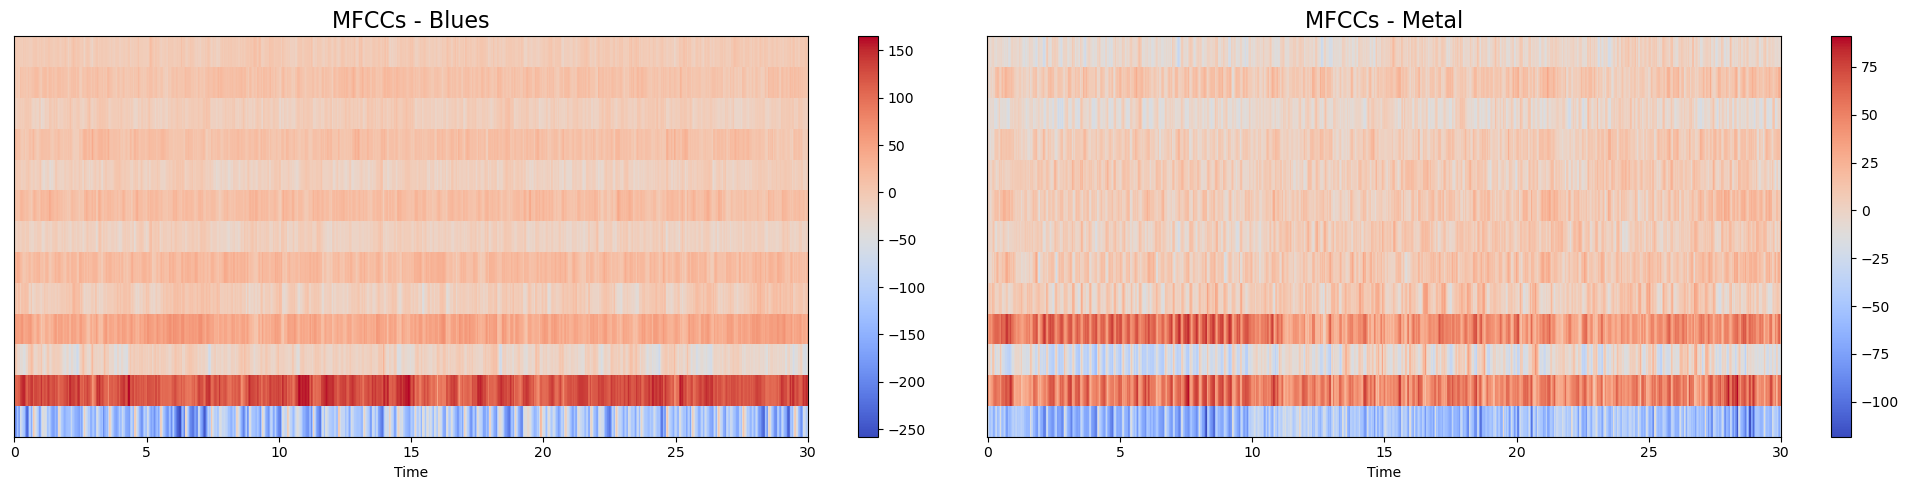

In [7]:
mfccs_blues = librosa.feature.mfcc(y=y_blues, sr=sr, n_mfcc=13)
mfccs_metal = librosa.feature.mfcc(y=y_metal, sr=sr, n_mfcc=13)

fig, ax = plt.subplots(1, 2, figsize=(20, 5))

img1 = librosa.display.specshow(mfccs_blues, x_axis='time', ax=ax[0])
ax[0].set_title('MFCCs - Blues')
fig.colorbar(img1, ax=ax[0])

img2 = librosa.display.specshow(mfccs_metal, x_axis='time', ax=ax[1])
ax[1].set_title('MFCCs - Metal')
fig.colorbar(img2, ax=ax[1])

plt.tight_layout()
plt.show()